In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
import Levenshtein
from random import choices, randint
from itertools import product
import torch
from tqdm import tqdm
from utils import *
from scipy.stats import ortho_group
from scipy.fftpack import dct

In [5]:
sequences = read_fasta_to_list('genome.fasta')
reference = read_fasta_to_list('reference.fasta')

100%|██████████| 1000/1000 [00:19<00:00, 51.37it/s]


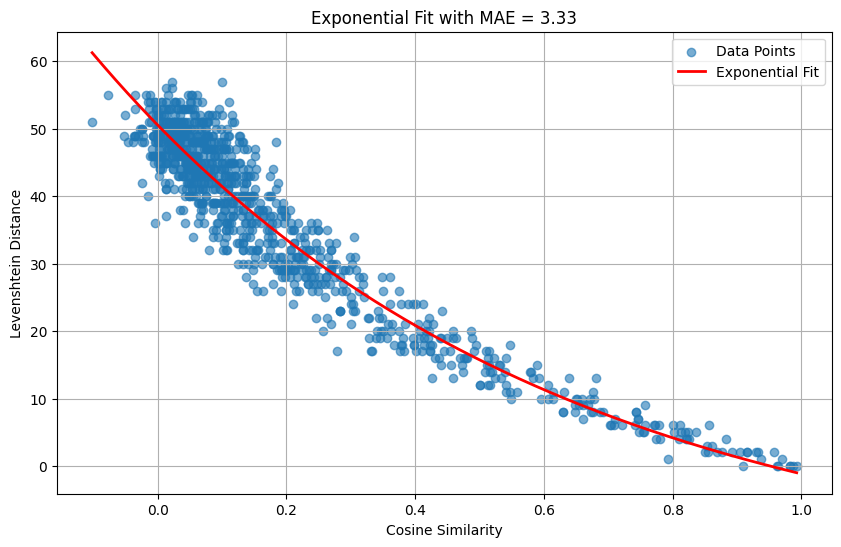

In [7]:
test_hierarchical_encoding_ropefrec_fast(k=5,sub_kmer_len=2, kmer_weight=0.6, num_pairs=1000, max_mutation_rate=0.9, random_pos=1.5, absolute=0.5, dct_type=2)

In [ ]:
kmer_weights = [i/10 for i in range(3,11)]
subkmer_lens = [2, 3,4]


[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


100%|██████████| 11/11 [06:24<00:00, 34.95s/it]


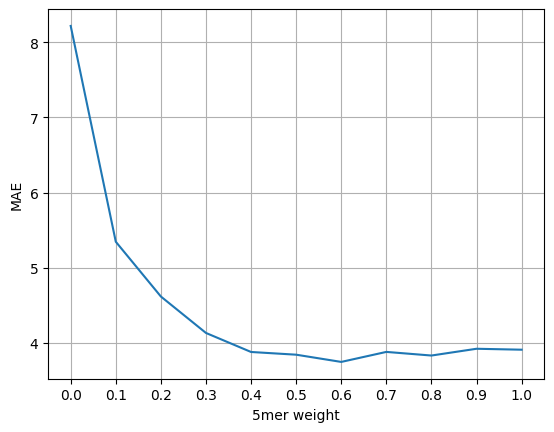

In [8]:
maes_kmer_weights = []
for kmer_weight in tqdm(kmer_weights):
    mae1 = test_hierarchical_encoding_ropefrec_fast_noplot(k=5, kmer_weight=kmer_weight, num_pairs=1000, max_mutation_rate=0.9, random_pos=1, absolute=1)
    mae2 = test_hierarchical_encoding_ropefrec_fast_noplot(k=5, kmer_weight=kmer_weight, num_pairs=1000, max_mutation_rate=0.9, random_pos=1, absolute=1)
    maes_kmer_weights.append((mae1 + mae2)/2)

plt.plot(kmer_weights, maes_kmer_weights)
plt.xlabel("5mer weight")
plt.ylabel("MAE")
plt.xticks(kmer_weights)
plt.grid(True)
plt.show()

100%|██████████| 4/4 [01:58<00:00, 29.59s/it]


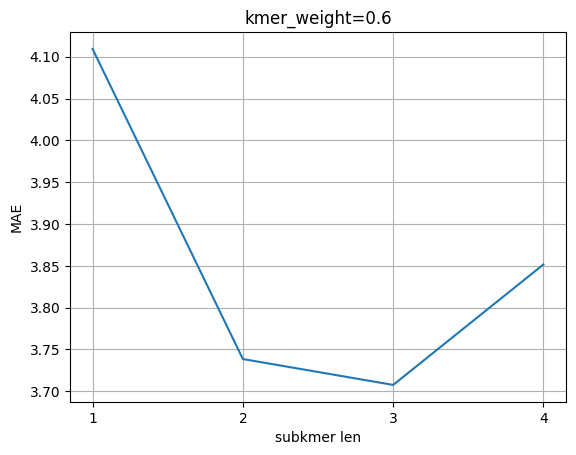

In [2]:
subkmer_lens = [1, 2, 3, 4]
maes_subkmer_lens = []
for subkmer_len in tqdm(subkmer_lens):
    mae1 = test_hierarchical_encoding_ropefrec_fast_noplot(k=5, sub_kmer_len=subkmer_len, kmer_weight=0.6, num_pairs=1000, max_mutation_rate=0.9, random_pos=1, absolute=1)
    mae2 = test_hierarchical_encoding_ropefrec_fast_noplot(k=5, sub_kmer_len=subkmer_len, kmer_weight=0.6, num_pairs=1000, max_mutation_rate=0.9, random_pos=1, absolute=1)
    maes_subkmer_lens.append((mae1 + mae2)/2)

plt.plot(subkmer_lens, maes_subkmer_lens)
plt.xlabel("subkmer len")
plt.ylabel("MAE")
plt.title("kmer_weight=0.6")
plt.xticks(subkmer_lens)
plt.grid(True)
plt.show()

100%|██████████| 1000/1000 [00:13<00:00, 75.69it/s]


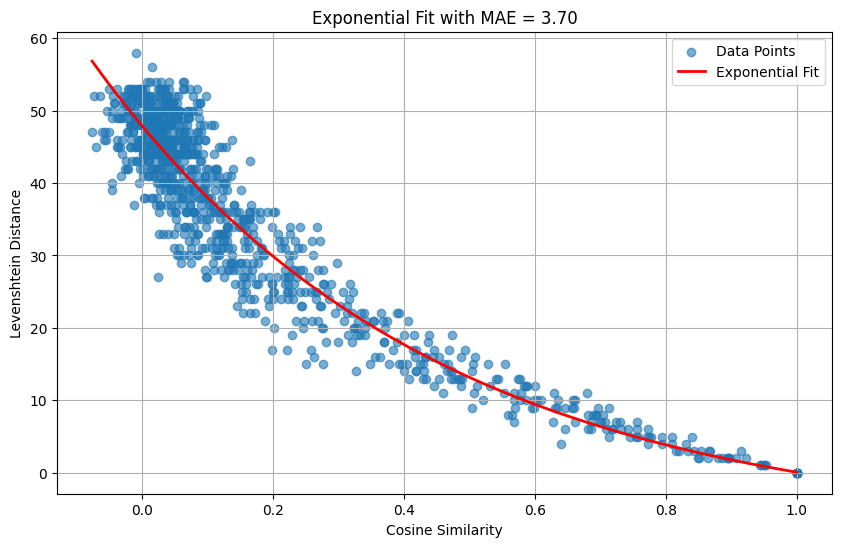

In [3]:
test_hierarchical_encoding_ropefrec_fast(k=5,sub_kmer_len=3, kmer_weight=0.6, num_pairs=1000, max_mutation_rate=0.9, random_pos=1, absolute=1)

100%|██████████| 1000/1000 [00:04<00:00, 234.28it/s]


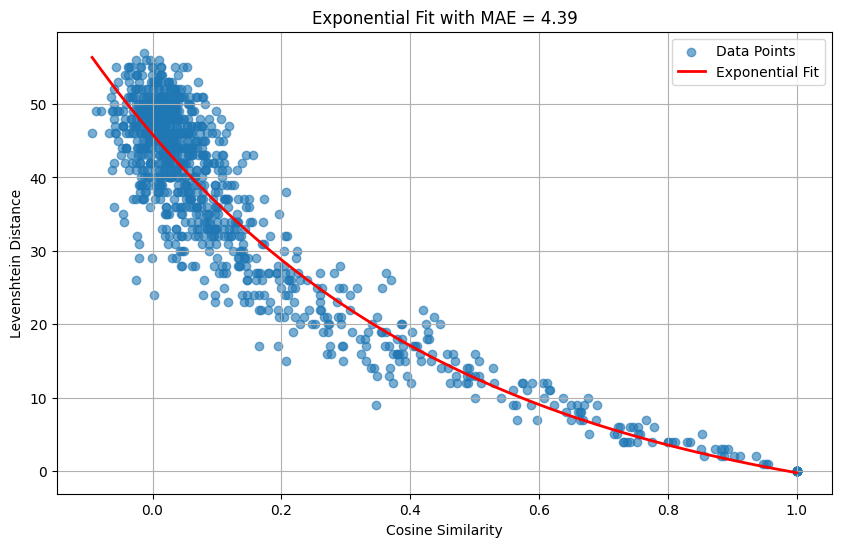

In [5]:
dim = 1024
theta = 1.0 / (10 ** (torch.arange(0, dim, 2).float() / dim))
test_encoding_ropefrec_fast(k=5, num_pairs=1000, max_mutation_rate=0.9, theta=theta, random_pos=1, absolute=1)

In [3]:
# dim = 1024
dim = 1040
theta = 1.0 / (10 ** (torch.arange(0, dim, 2).float() / dim))
rotation_matrices = {}
rotation_vectors = {}
random_rotation = ortho_group.rvs(dim=dim)

In [4]:
one_hot = np.array([0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0])
np.dot(one_hot, ortho_group.rvs(dim=one_hot.shape[0]))

array([ 0.14957601,  0.3383313 , -0.53374885,  0.02402141,  0.04070858,
        0.2602872 , -0.12719386,  0.12263253, -0.01958536, -0.07152632,
        0.00108957,  0.11906658, -0.27457898, -0.06167439,  0.24788736,
       -0.5628031 ])

In [5]:
dct_one_hot = dct(one_hot, type=4, norm='ortho')
print(dct_one_hot)
norm_dct_one_hot = np.linalg.norm(dct_one_hot)
print(norm_dct_one_hot)

[ 0.34972671  0.31960848  0.26196578  0.18176277  0.08590647 -0.01734804
 -0.11910855 -0.21061151 -0.28397675 -0.3328861  -0.35312752 -0.34295784
 -0.30325286 -0.23743195 -0.15116355 -0.05187706]
1.0000000000000002


100%|██████████| 1000/1000 [00:16<00:00, 59.96it/s]


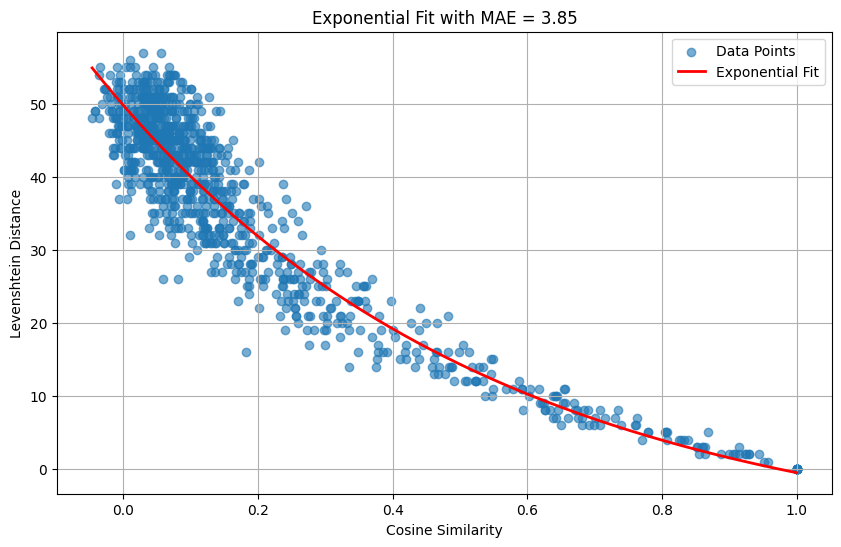

In [4]:
test_hierarchical_encoding_ropefrec_fast(k=5, num_pairs=1000, max_mutation_rate=0.9, random_pos=1, absolute=1)

100%|██████████| 1000/1000 [00:16<00:00, 61.50it/s]


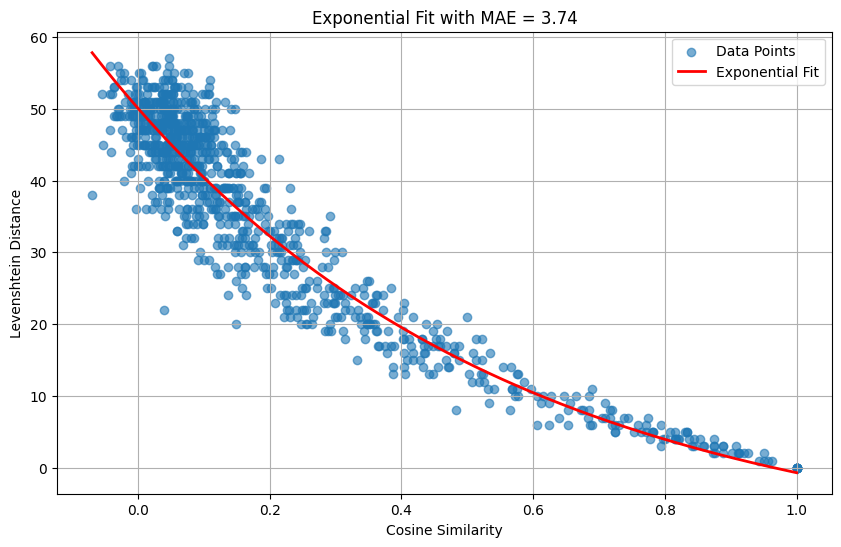

In [10]:
dim = 1040
theta = 1.0 / (10 ** (torch.arange(0, dim, 2).float() / dim))
test_hierarchical_encoding_ropefrec_fast(k=5, num_pairs=1000, max_mutation_rate=0.9, theta=theta, random_pos=1, absolute=1)

100%|██████████| 1000/1000 [00:04<00:00, 240.80it/s]


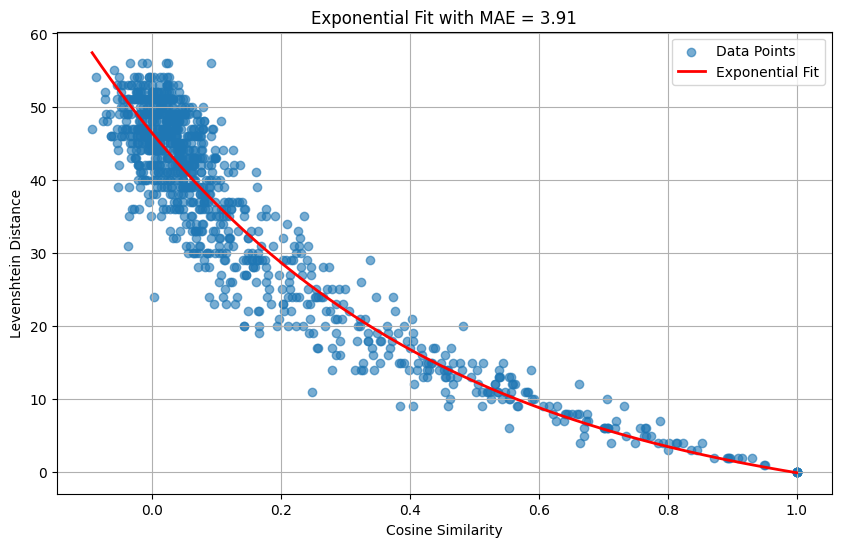

In [9]:
dim = 1024
theta = 1.0 / (10 ** (torch.arange(0, dim, 2).float() / dim))
test_encoding_ropefrec_fast(k=5, num_pairs=1000, max_mutation_rate=0.9, theta=theta, random_pos=1, absolute=1)

100%|██████████| 1000/1000 [00:41<00:00, 24.06it/s]


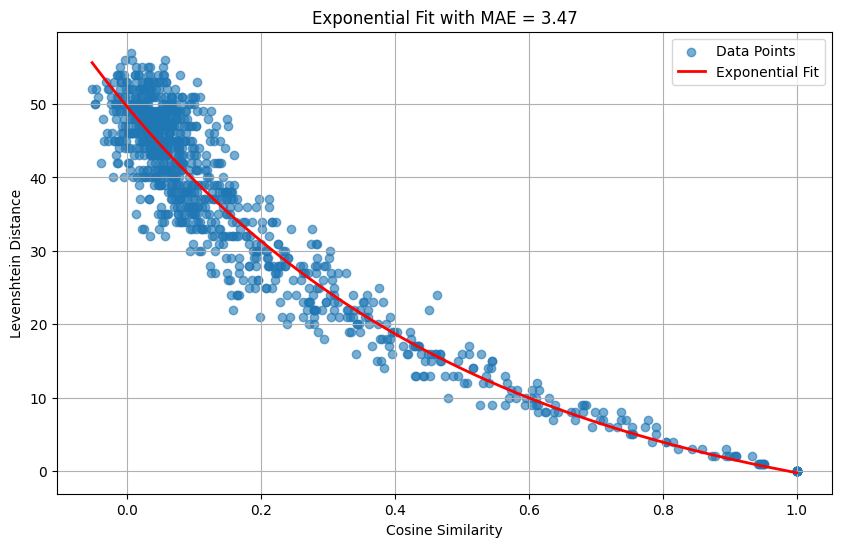

In [ ]:

test_encoding_ropefrec_fast(k=5, num_pairs=1000, max_mutation_rate=0.9, theta=theta, random_pos=1, absolute=1, random_rotation=random_rotation)

100%|██████████| 1000/1000 [00:04<00:00, 226.65it/s]


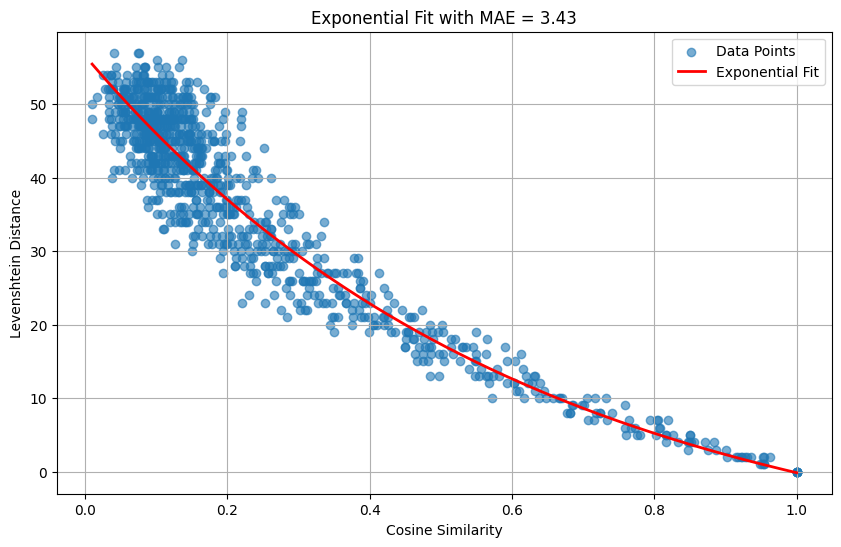

In [ ]:
test_encoding_ropefrec_fast(k=5, num_pairs=1000, max_mutation_rate=0.9, theta=theta, random_pos=1, absolute=1, dct_type=None)

100%|██████████| 1000/1000 [00:05<00:00, 192.84it/s]


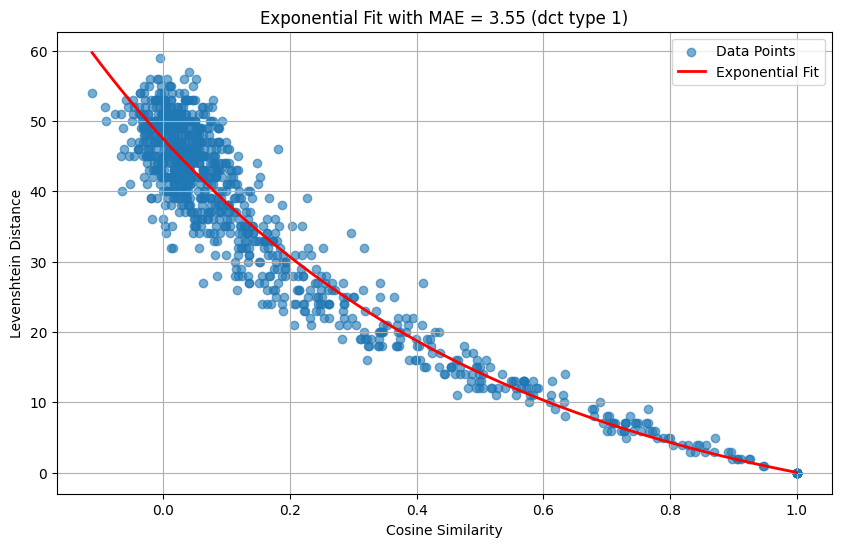

In [ ]:
test_encoding_ropefrec_fast(k=5, num_pairs=1000, max_mutation_rate=0.9, theta=theta, random_pos=1, absolute=1, dct_type=1, caption='dct type 1')

100%|██████████| 1000/1000 [00:05<00:00, 195.18it/s]


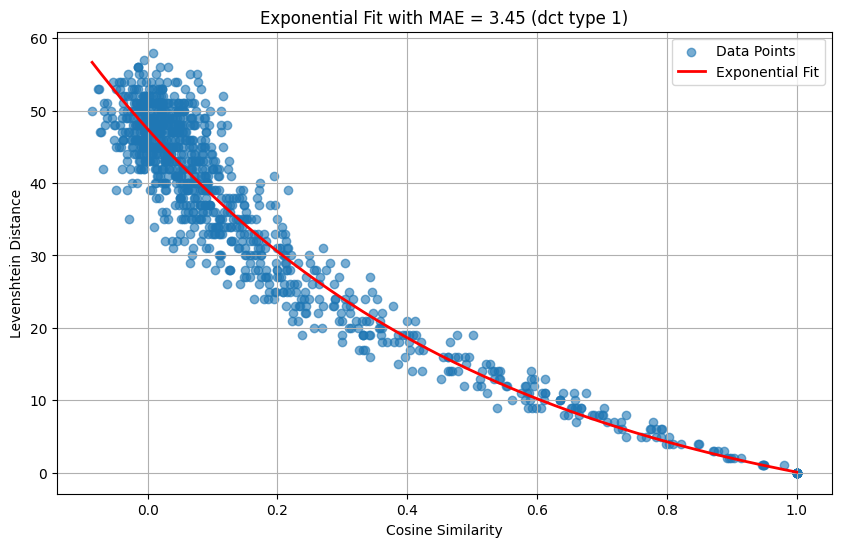

100%|██████████| 1000/1000 [00:04<00:00, 224.88it/s]


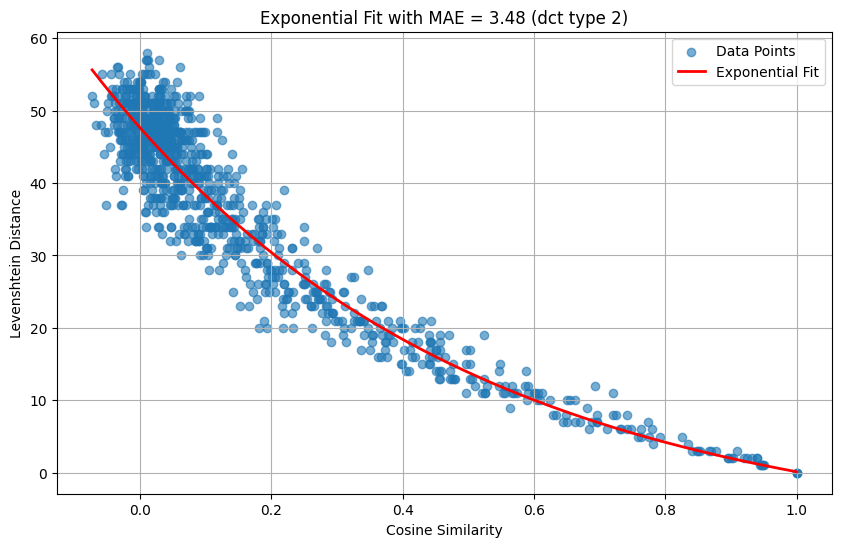

100%|██████████| 1000/1000 [00:04<00:00, 225.64it/s]


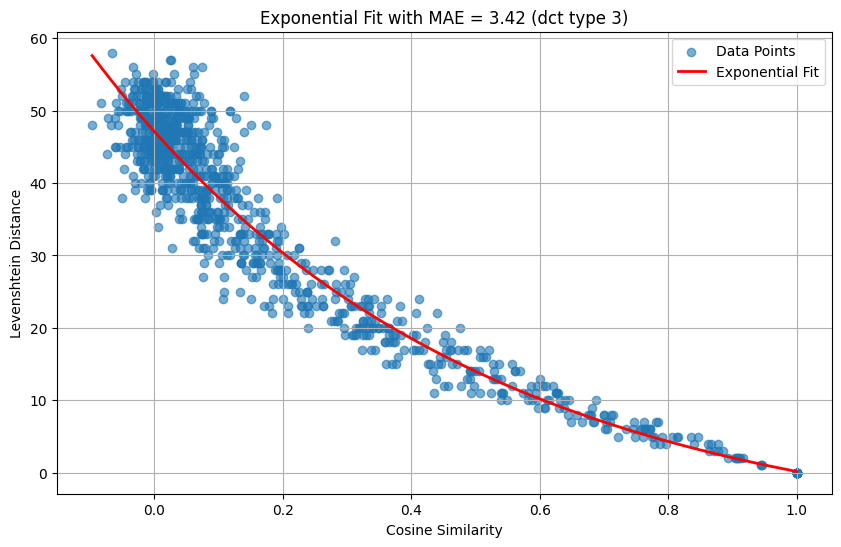

100%|██████████| 1000/1000 [00:04<00:00, 225.51it/s]


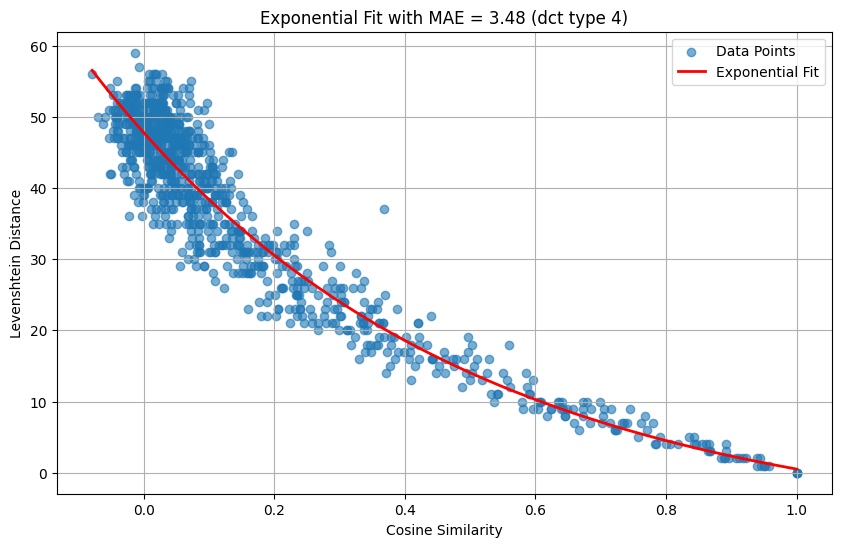

In [7]:
test_encoding_ropefrec_fast(k=5, num_pairs=1000, max_mutation_rate=0.9, theta=theta, random_pos=1, absolute=1, dct_type=1, caption='dct type 1')
test_encoding_ropefrec_fast(k=5, num_pairs=1000, max_mutation_rate=0.9, theta=theta, random_pos=1, absolute=1, dct_type=2, caption='dct type 2')
test_encoding_ropefrec_fast(k=5, num_pairs=1000, max_mutation_rate=0.9, theta=theta, random_pos=1, absolute=1, dct_type=3, caption='dct type 3')    
test_encoding_ropefrec_fast(k=5, num_pairs=1000, max_mutation_rate=0.9, theta=theta, random_pos=1, absolute=1, dct_type=4, caption='dct type 4')

100%|██████████| 1000/1000 [00:04<00:00, 241.23it/s]


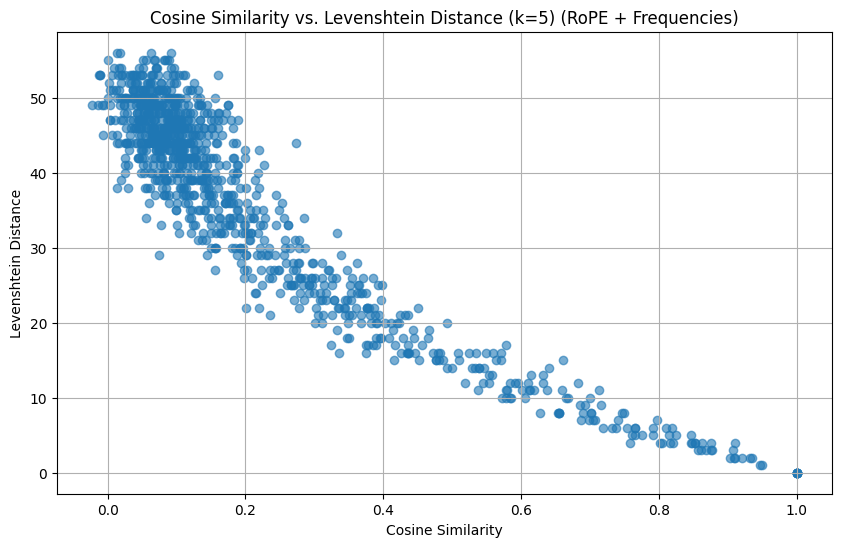

In [7]:
test_encoding_ropefrec_fast(k=5, num_pairs=1000, max_mutation_rate=0.9, theta=theta, random_pos=1, absolute=1)

100%|██████████| 1000/1000 [00:22<00:00, 45.18it/s]


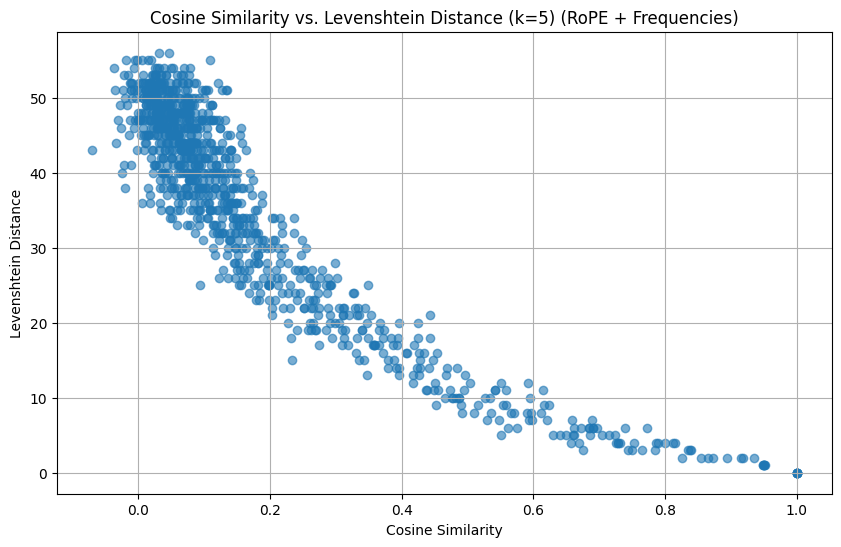

In [8]:
test_encoding_ropefrec_fast(k=5, num_pairs=1000, max_mutation_rate=0.9, theta=theta, random_pos=1, absolute=1.5, random_rotation=random_rotation)

In [14]:

x = torch.tensor([1, 2, 3, 4, 5,6,7,8])
y = torch.empty_like(x)
y[::2] = -x[1::2]  # [-2, _, -4, _]
y[1::2] = x[::2]   # [_, 1, _, 3]

print(y) 

tensor([-2,  1, -4,  3, -6,  5, -8,  7])


In [9]:
position = 1
angles = position * theta.repeat_interleave(2)
sin_vals = torch.sin(angles)
cos_vals = torch.cos(angles)

In [10]:
len(theta)

512

## Rotary Position + Frequency Encoding (RANDOM PAIRS)

100%|██████████| 1000/1000 [00:28<00:00, 35.58it/s]


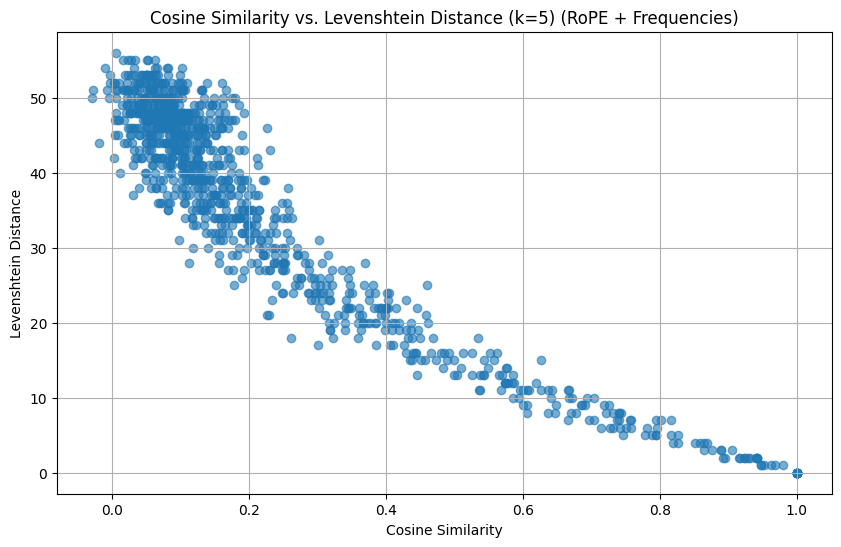

In [ ]:
test_encoding_ropefrec(k=5, num_pairs=1000, max_mutation_rate=0.9)

## Frequency Encoding (RANDOM PAIRS)

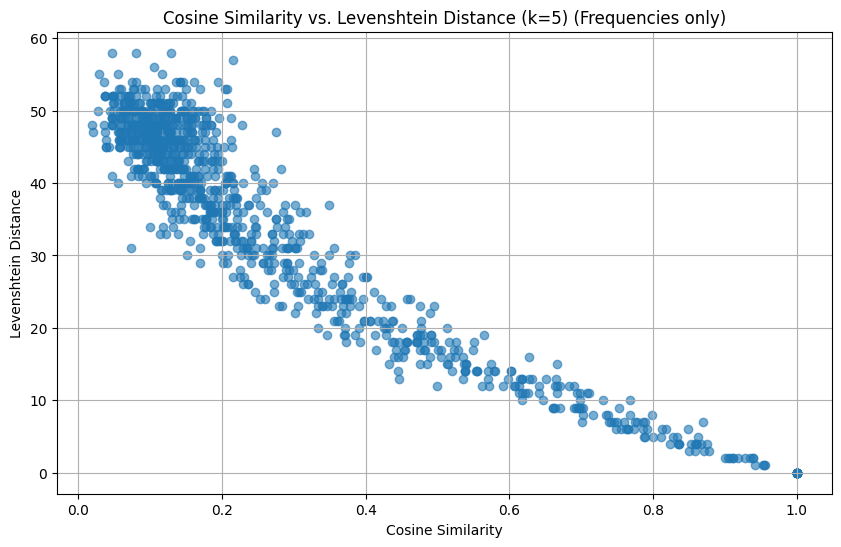

In [ ]:
test_encoding_frec(k=5, num_pairs=1000, max_mutation_rate=0.9)

## SAMPLED FROM PHI174

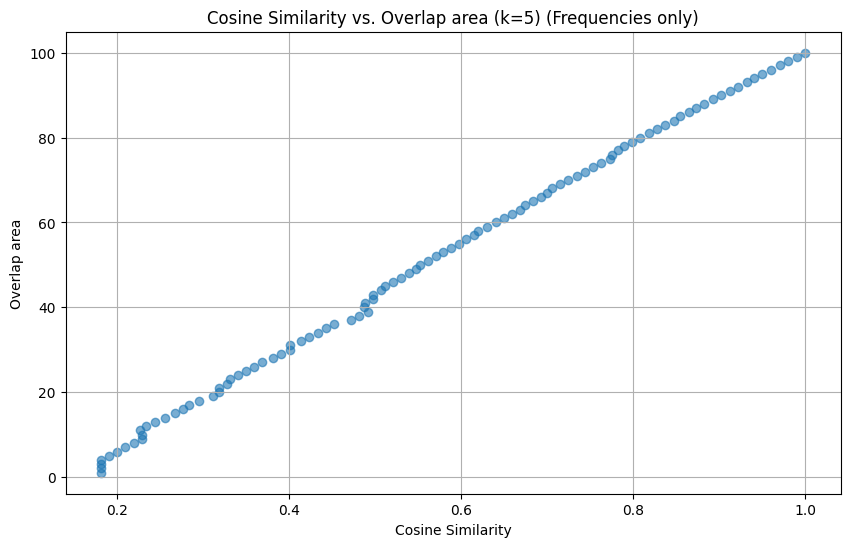

In [21]:
overlapping_pairs = create_overlapping_pairs(reference[0])
test_encoding_frec_overlap(pairs=overlapping_pairs)

## SAMPLED OVERLAPING PAIRS

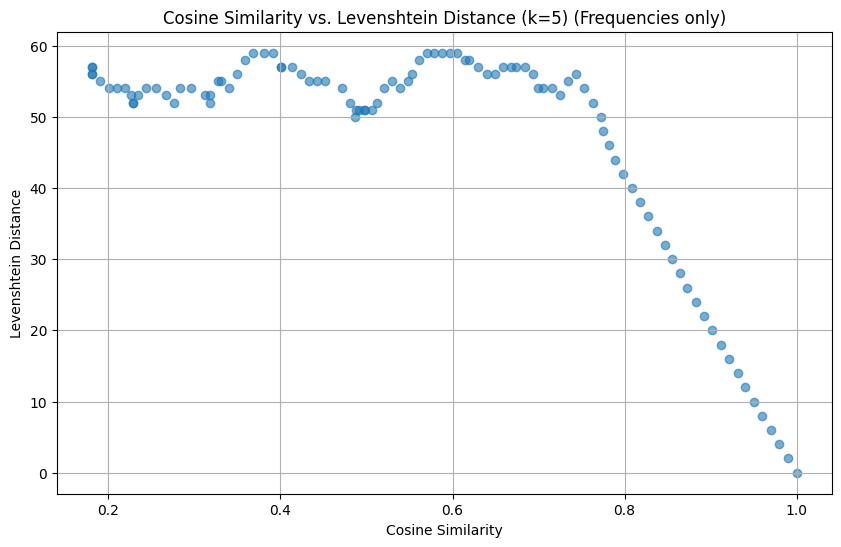

In [22]:
# pairs = create_pairs(sequences, reference[0], n=100)
# test_encoding_frec(k=5, num_pairs=1000, max_mutation_rate=0.9, pairs=pairs)
overlapping_pairs = create_overlapping_pairs(reference[0])
test_encoding_frec(k=5, num_pairs=1000, max_mutation_rate=0.9, pairs=overlapping_pairs)

## Frequency Encoding (SAMPLED FROM PHIX174)

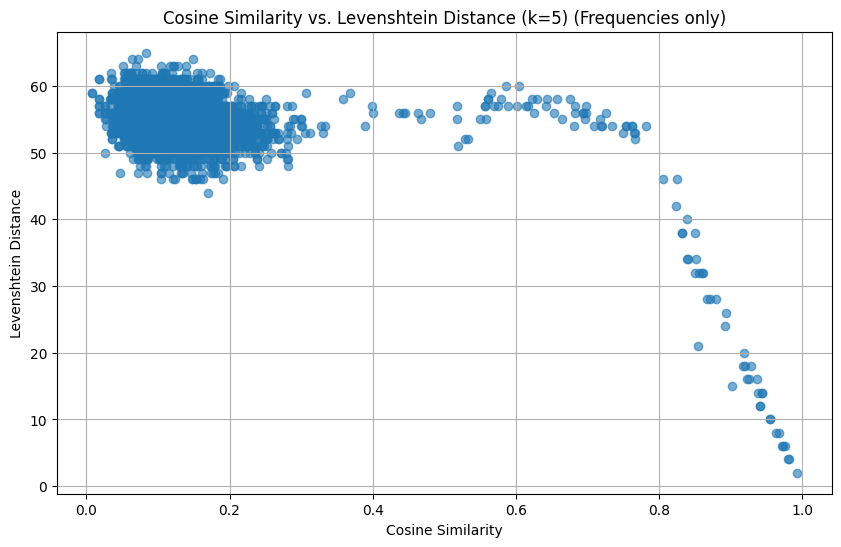

In [10]:
pairs = create_pairs(sequences, reference[0], n=100)
test_encoding_frec(k=5, num_pairs=1000, max_mutation_rate=0.9, pairs=pairs)

100%|██████████| 5300/5300 [00:08<00:00, 591.63it/s]


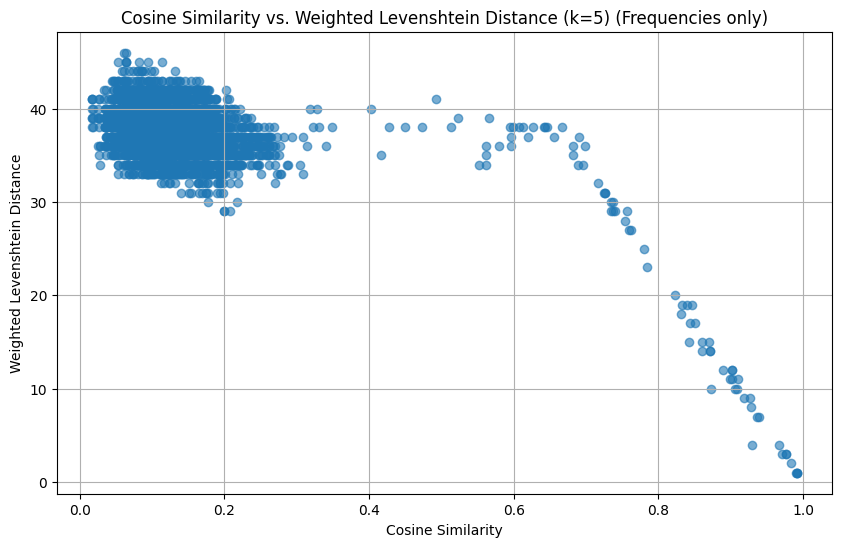

In [3]:
pairs = create_pairs(sequences, reference[0], n=100)
test_encoding_frec_weighted(k=5, num_pairs=1000, max_mutation_rate=0.9, pairs = pairs)

In [12]:
print(reference[0][:100])
print(reference[0][25:125])
print(reference[0][10:110])

GAGTTTTATCGCTTCCATGACGCAGAAGTTAACACTTTCGGATATTTCTGATGAGTCGAAAAATTATCTTGATAAAGCAGGAATTACTACTGCTTGTTTA
AAGTTAACACTTTCGGATATTTCTGATGAGTCGAAAAATTATCTTGATAAAGCAGGAATTACTACTGCTTGTTTACGAATTAAATCGAAGTGGACTGCTG
GCTTCCATGACGCAGAAGTTAACACTTTCGGATATTTCTGATGAGTCGAAAAATTATCTTGATAAAGCAGGAATTACTACTGCTTGTTTACGAATTAAAT
